# Explainable AI-Enhanced ML — Cardiovascular Disease Detection (Framingham)
> **Dataset:** Framingham Heart Study | **Target:** `TenYearCHD`  
> **Paper:** Explainable AI-Enhanced ML Approach for CVD Detection and Risk Assessment  
> **Improvement:** Risk-Aware Explainable Random Forest (RAERF)

In [4]:
!pip install -q imbalanced-learn shap lime catboost lightgbm xgboost pytorch-tabnet scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.6 MB/s eta 0:00:00


In [5]:
import warnings
warnings.filterwarnings('ignore')
import copy, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, roc_curve, auc,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from pytorch_tabnet.tab_model import TabNetClassifier
from imblearn.over_sampling import SMOTE
import shap
import lime
import lime.lime_tabular

shap.initjs()
print('All imports successful!')

All imports successful!


## 2. Load Dataset
Set `DATASET_PATH` to your CSV filename (Framingham format).

In [6]:
# UPDATE THIS PATH
DATASET_PATH = 'heart_disease.csv'

# Framingham columns
CLF_TARGET = 'TenYearCHD'
FEATURE_COLS = [
    'male', 'age', 'education', 'currentSmoker', 'cigsPerDay',
    'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes',
    'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose'
]

df_raw = pd.read_csv(DATASET_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
print(f'Class distribution: {df_raw[CLF_TARGET].value_counts().to_dict()}')
df_raw.head()

Shape: (4240, 16)
Columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
Class distribution: {0: 3596, 1: 644}


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 3. Exploratory Data Analysis

In [7]:
print('Missing values:')
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f'Total missing: {missing.sum()}')
df_raw.describe()

Missing values:
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64
Total missing: 645


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


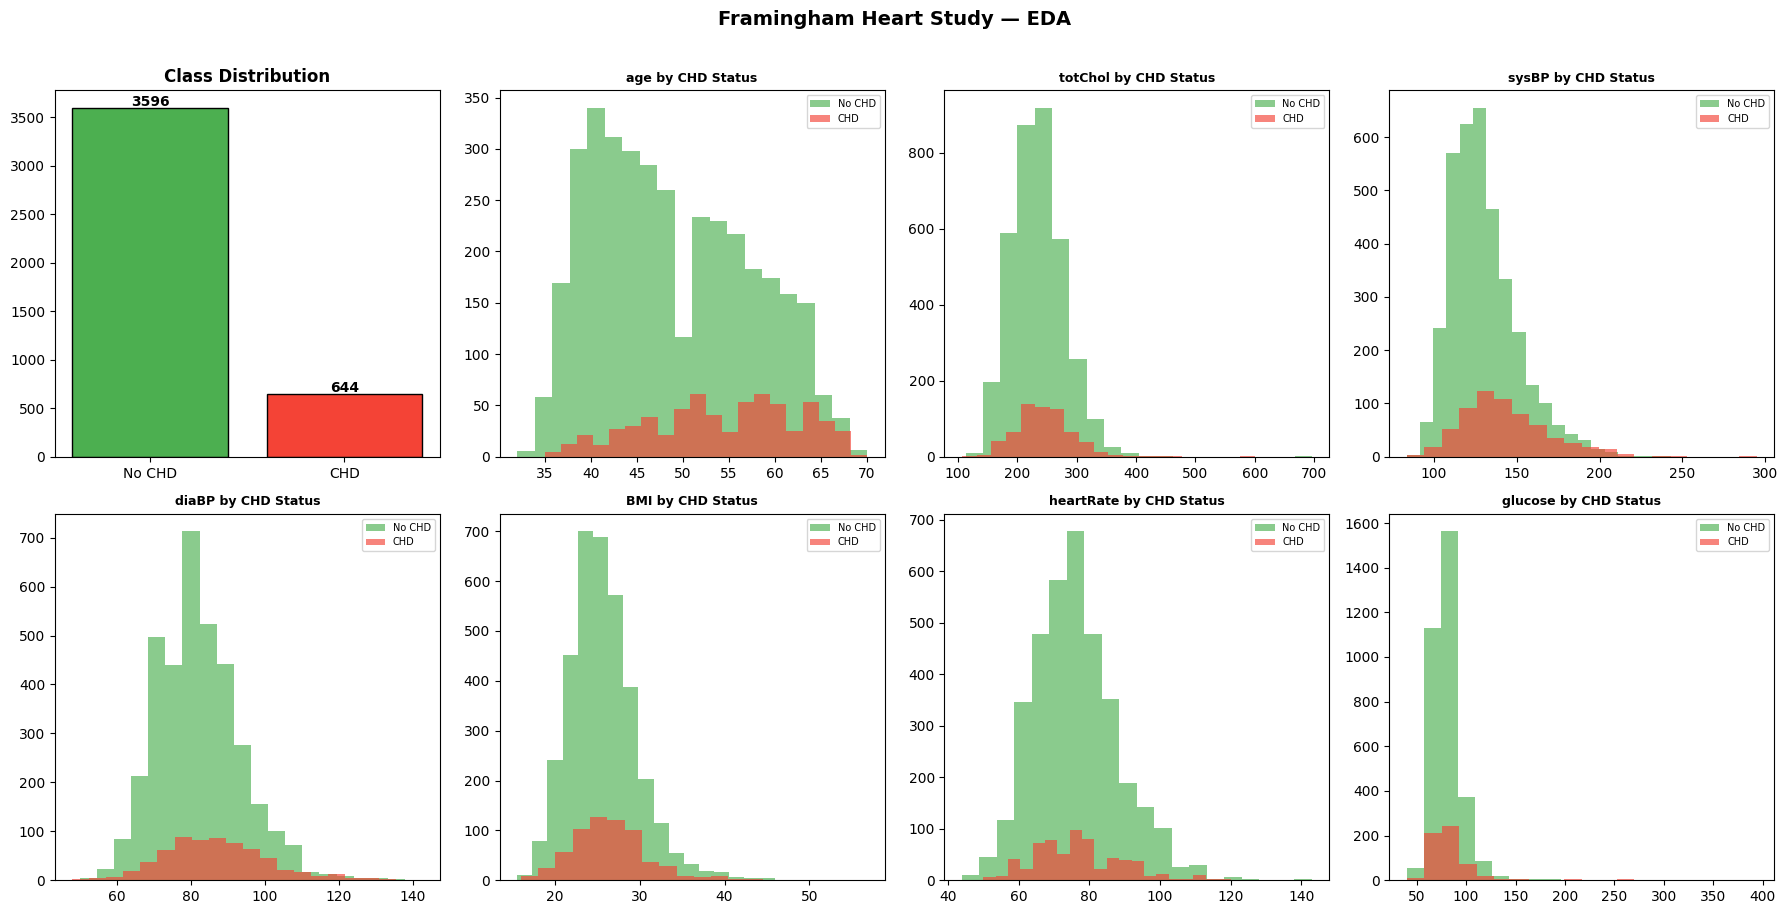

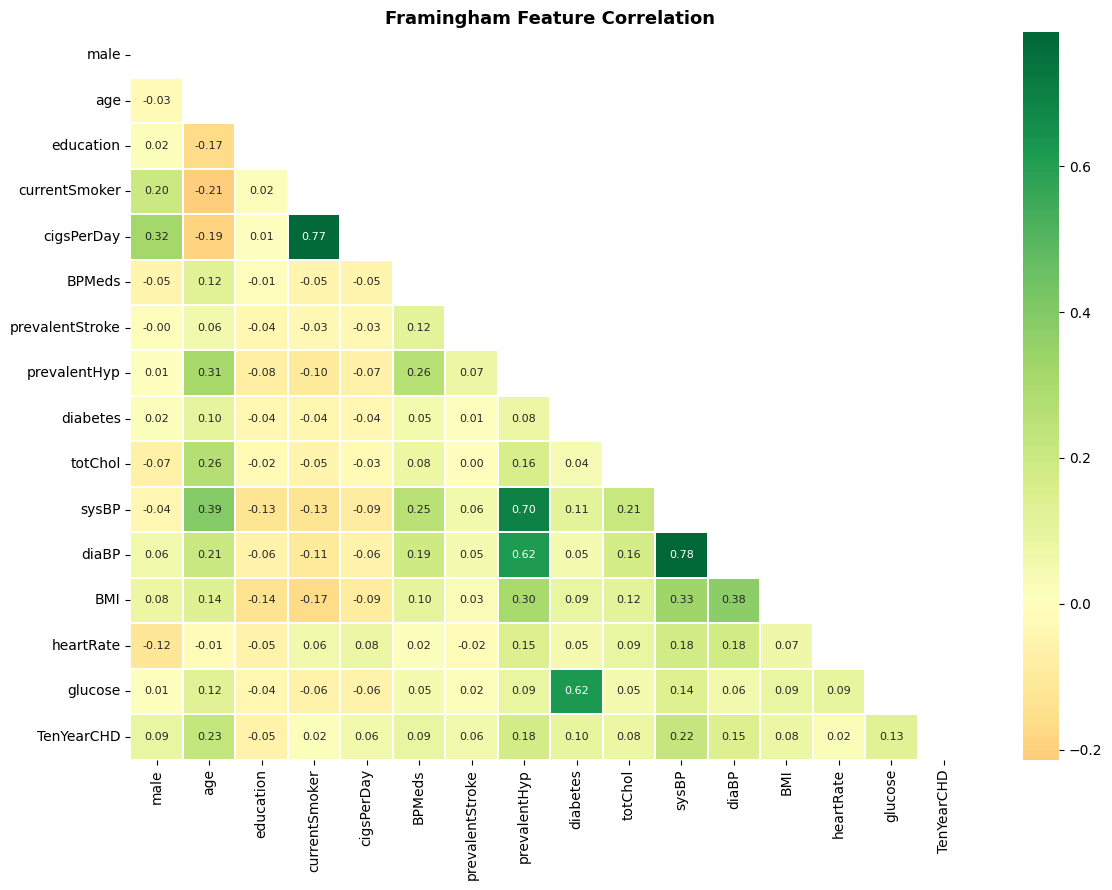

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Class distribution
cnt = df_raw[CLF_TARGET].value_counts().sort_index()
bars = axes[0].bar(['No CHD', 'CHD'], cnt.values, color=['#4CAF50','#F44336'], edgecolor='black')
for bar, v in zip(bars, cnt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')

# Numeric features by class
plot_cols = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
for i, col in enumerate(plot_cols):
    ax = axes[i+1]
    for val, color, lbl in [(0,'#4CAF50','No CHD'),(1,'#F44336','CHD')]:
        subset = df_raw[df_raw[CLF_TARGET]==val][col].dropna()
        ax.hist(subset, bins=20, alpha=0.65, label=lbl, color=color)
    ax.set_title(f'{col} by CHD Status', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Framingham Heart Study — EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap
fig2, ax2 = plt.subplots(figsize=(12, 9))
corr = df_raw.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax2, cmap='RdYlGn', center=0,
            linewidths=0.3, annot=True, fmt='.2f', annot_kws={'size':8})
ax2.set_title('Framingham Feature Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [9]:
df = df_raw.copy()

# 4.1 Impute missing values
binary_cols = ['male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes']
continuous_fc = [c for c in FEATURE_COLS if c not in binary_cols and c in df.columns]

for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue
    if col in binary_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print(f'Missing after imputation: {df.isnull().sum().sum()}')

# 4.2 IQR outlier removal on continuous features
def remove_iqr(data, cols):
    d = data.copy()
    n0 = len(d)
    for col in cols:
        if col not in d.columns: continue
        Q1, Q3 = d[col].quantile(0.25), d[col].quantile(0.75)
        IQR = Q3 - Q1
        d = d[(d[col] >= Q1-1.5*IQR) & (d[col] <= Q3+1.5*IQR)]
    print(f'IQR: {n0} -> {len(d)} rows (removed {n0-len(d)})')
    return d.reset_index(drop=True)

df = remove_iqr(df, continuous_fc)
print(f'Clean shape: {df.shape}')
print(f'Class balance: {df[CLF_TARGET].value_counts().to_dict()}')

Missing after imputation: 0
IQR: 4240 -> 3632 rows (removed 608)
Clean shape: (3632, 16)
Class balance: {0: 3150, 1: 482}


In [10]:
df = df_raw.copy()

# 4.1 Impute missing values
binary_cols = ['male','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes']
continuous_fc = [c for c in FEATURE_COLS if c not in binary_cols and c in df.columns]

for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue
    if col in binary_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print(f'Missing after imputation: {df.isnull().sum().sum()}')

# 4.2 IQR outlier removal on continuous features
def remove_iqr(data, cols):
    d = data.copy()
    n0 = len(d)
    for col in cols:
        if col not in d.columns: continue
        Q1, Q3 = d[col].quantile(0.25), d[col].quantile(0.75)
        IQR = Q3 - Q1
        d = d[(d[col] >= Q1-1.5*IQR) & (d[col] <= Q3+1.5*IQR)]
    print(f'IQR: {n0} -> {len(d)} rows (removed {n0-len(d)})')
    return d.reset_index(drop=True)

df = remove_iqr(df, continuous_fc)
print(f'Clean shape: {df.shape}')
print(f'Class balance: {df[CLF_TARGET].value_counts().to_dict()}')

# 4.3 Build X and targets
FEAT_AVAIL = [c for c in FEATURE_COLS if c in df.columns]

X        = df[FEAT_AVAIL].values.astype(np.float32)
y_clf    = df[CLF_TARGET].values.astype(int)

# Build continuous risk score (regression target) from key Framingham risk factors
RISK_WEIGHTS = {
    'age':0.20, 'sysBP':0.15, 'totChol':0.12, 'glucose':0.12,
    'cigsPerDay':0.10, 'BMI':0.08, 'diaBP':0.07, 'heartRate':0.06,
    'diabetes':0.04, 'prevalentHyp':0.03, 'male':0.02, 'currentSmoker':0.01
}
risk_score = np.zeros(len(df))
total_w = 0
for col, w in RISK_WEIGHTS.items():
    if col in FEAT_AVAIL:
        idx = FEAT_AVAIL.index(col)
        v = X[:, idx]
        vn = (v - v.min()) / (np.ptp(v) + 1e-9)
        risk_score += w * vn
        total_w += w
risk_score /= total_w
y_reg = (0.65*risk_score + 0.35*y_clf.astype(float)).astype(np.float32)
y_reg = (y_reg - y_reg.min()) / (np.ptp(y_reg) + 1e-9)

# 4.4 Scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4.5 80/20 split
X_tr, X_te, y_clf_tr, y_clf_te = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
_, _, y_reg_tr, y_reg_te = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

print(f'Features  : {FEAT_AVAIL}')
print(f'Train     : {X_tr.shape}  |  Test: {X_te.shape}')
print(f'Risk score: min={y_reg.min():.3f}  max={y_reg.max():.3f}  mean={y_reg.mean():.3f}')

Missing after imputation: 0
IQR: 4240 -> 3632 rows (removed 608)
Clean shape: (3632, 16)
Class balance: {0: 3150, 1: 482}
Features  : ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
Train     : (2905, 15)  |  Test: (727, 15)
Risk score: min=0.000  max=1.000  mean=0.306


## 5. SMOTE

Original  : {0: np.int64(3150), 1: np.int64(482)}
After SMOTE: {0: np.int64(3150), 1: np.int64(3150)}


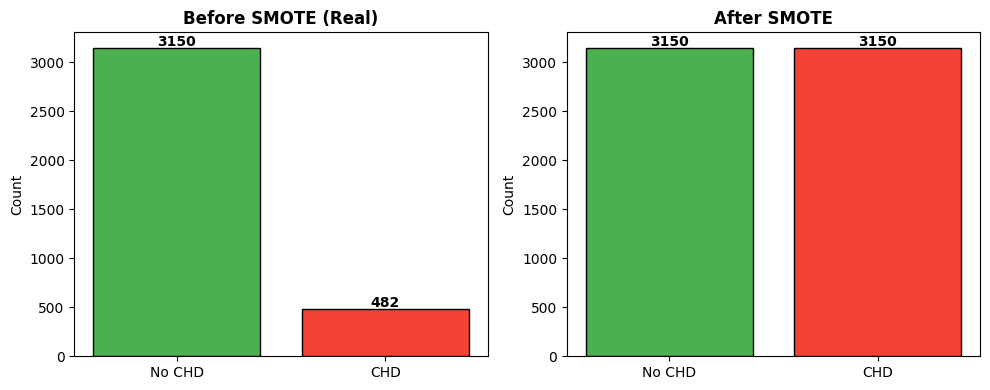

In [11]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_syn, y_clf_syn = smote.fit_resample(X_scaled, y_clf)

# Derive regression target for synthetic samples
X_syn_inv = scaler.inverse_transform(X_syn)
r_syn = np.zeros(len(X_syn))
tw = 0
for col, w in RISK_WEIGHTS.items():
    if col in FEAT_AVAIL:
        idx = FEAT_AVAIL.index(col)
        v = X_syn_inv[:, idx]
        # FIXED: Using np.ptp(v) instead of v.ptp() for NumPy 2.0 compatibility
        vn = (v - v.min()) / (np.ptp(v) + 1e-9)
        r_syn += w * vn; tw += w
r_syn /= tw
y_reg_syn = (0.65*r_syn + 0.35*y_clf_syn.astype(float)).astype(np.float32)
y_reg_syn = (y_reg_syn - y_reg_syn.min()) / (np.ptp(y_reg_syn) + 1e-9)

print(f'Original  : {dict(pd.Series(y_clf).value_counts().sort_index())}')
print(f'After SMOTE: {dict(pd.Series(y_clf_syn).value_counts().sort_index())}')

X_syn_tr, X_syn_te, y_clf_syn_tr, y_clf_syn_te = train_test_split(
    X_syn, y_clf_syn, test_size=0.2, random_state=42)
_, _, y_reg_syn_tr, y_reg_syn_te = train_test_split(
    X_syn, y_reg_syn, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, title in [(axes[0], y_clf,'Before SMOTE (Real)'), (axes[1], y_clf_syn,'After SMOTE')]:
    c = pd.Series(y).value_counts().sort_index()
    bars = ax.bar(['No CHD','CHD'], c.values, color=['#4CAF50','#F44336'], edgecolor='black')
    for bar, v in zip(bars, c.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(v), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('smote.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation Helpers

In [12]:
def eval_clf(model, Xte, yte):
    yp = model.predict(Xte)
    return dict(
        Accuracy  = round(accuracy_score(yte, yp), 3),
        MCC       = round(matthews_corrcoef(yte, yp), 3),
        Precision = round(precision_score(yte, yp, zero_division=0), 3),
        Recall    = round(recall_score(yte, yp, zero_division=0), 3),
        F1        = round(f1_score(yte, yp, zero_division=0), 3),
    )

def eval_reg(model, Xte, yte):
    yp = model.predict(Xte)
    mse = mean_squared_error(yte, yp)
    return dict(
        R2   = round(r2_score(yte, yp), 3),
        MSE  = round(float(mse), 4),
        RMSE = round(float(np.sqrt(mse)), 4),
        MAE  = round(float(mean_absolute_error(yte, yp)), 4),
    )

def run_clf(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    m = eval_clf(model, Xte, yte)
    print(f'  {name:<22}  Acc={m["Accuracy"]:.3f}  F1={m["F1"]:.3f}  MCC={m["MCC"]:.3f}')
    return model, m

def run_reg(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    m = eval_reg(model, Xte, yte)
    print(f'  {name:<22}  R2={m["R2"]:.3f}  MSE={m["MSE"]:.4f}  MAE={m["MAE"]:.4f}')
    return model, m

print('Helpers ready.')

Helpers ready.


## 7. Classification Models — Table I

In [13]:
def make_clfs():
    return {
        'SVM':           SVC(probability=True, random_state=42),
        'Gaussian NB':   GaussianNB(),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'KNN':           KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        'Grad Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
        'XGBoost':       XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
        'LightGBM':      LGBMClassifier(random_state=42, verbose=-1),
        'CatBoost':      CatBoostClassifier(random_state=42, verbose=0),
        'TabNet':        TabNetClassifier(verbose=0, seed=42),
    }

clf_real, clf_syn_res = {}, {}
trained_clf_real, trained_clf_syn = {}, {}

print('=== CLASSIFICATION — REAL DATA ===')
for name, model in make_clfs().items():
    try:
        m, metrics = run_clf(name, model, X_tr, y_clf_tr, X_te, y_clf_te)
        clf_real[name] = metrics; trained_clf_real[name] = m
    except Exception as e:
        print(f'  {name:<22}  ERROR: {e}')

print('\n=== CLASSIFICATION — SYNTHETIC (SMOTE) ===')
for name, model in make_clfs().items():
    try:
        m2 = copy.deepcopy(model)
        m2, metrics = run_clf(name, m2, X_syn_tr, y_clf_syn_tr, X_syn_te, y_clf_syn_te)
        clf_syn_res[name] = metrics; trained_clf_syn[name] = m2
    except Exception as e:
        print(f'  {name:<22}  ERROR: {e}')

=== CLASSIFICATION — REAL DATA ===
  SVM                     Acc=0.868  F1=0.020  MCC=0.057
  Gaussian NB             Acc=0.846  F1=0.164  MCC=0.109
  Random Forest           Acc=0.869  F1=0.021  MCC=0.095
  Decision Tree           Acc=0.781  F1=0.306  MCC=0.183
  KNN                     Acc=0.860  F1=0.089  MCC=0.080
  Grad Boosting           Acc=0.862  F1=0.107  MCC=0.108
  XGBoost                 Acc=0.853  F1=0.130  MCC=0.095
  LightGBM                Acc=0.856  F1=0.118  MCC=0.092
  CatBoost                Acc=0.871  F1=0.078  MCC=0.144
  TabNet                  Acc=0.851  F1=0.085  MCC=0.050

=== CLASSIFICATION — SYNTHETIC (SMOTE) ===
  SVM                     Acc=0.748  F1=0.760  MCC=0.499
  Gaussian NB             Acc=0.635  F1=0.549  MCC=0.294
  Random Forest           Acc=0.921  F1=0.922  MCC=0.843
  Decision Tree           Acc=0.835  F1=0.841  MCC=0.671
  KNN                     Acc=0.809  F1=0.838  MCC=0.659
  Grad Boosting           Acc=0.873  F1=0.870  MCC=0.747
  XGBoost

In [15]:
rows = []
for name in clf_real:
    r, s = clf_real[name], clf_syn_res.get(name, {})
    rows.append({'Model':name,
        'Acc(R)':r.get('Accuracy','-'), 'Acc(S)':s.get('Accuracy','-'),
        'MCC(R)':r.get('MCC','-'),      'MCC(S)':s.get('MCC','-'),
        'Prec(R)':r.get('Precision','-'),'Prec(S)':s.get('Precision','-'),
        'Rec(R)':r.get('Recall','-'),   'Rec(S)':s.get('Recall','-'),
        'F1(R)':r.get('F1','-'),        'F1(S)':s.get('F1','-'),
    })
table1 = pd.DataFrame(rows).set_index('Model')
print('=== TABLE I — Classification Performance (R=Real, S=Synthetic/SMOTE) ===')
display(table1)

=== TABLE I — Classification Performance (R=Real, S=Synthetic/SMOTE) ===


,Acc(R),Acc(S),MCC(R),MCC(S),Prec(R),Prec(S),Rec(R),Rec(S),F1(R),F1(S)
Model,,,,,,,,,,
SVM,0.868,0.748,0.057,0.499,0.500,0.729,0.010,0.794,0.020,0.760
Gaussian NB,0.846,0.635,0.109,0.294,0.289,0.722,0.115,0.443,0.164,0.549
Random Forest,0.869,0.921,0.095,0.843,1.000,0.913,0.010,0.932,0.021,0.922
Decision Tree,0.781,0.835,0.183,0.671,0.263,0.814,0.365,0.870,0.306,0.841
KNN,0.860,0.809,0.080,0.659,0.312,0.729,0.052,0.984,0.089,0.838
Grad Boosting,0.862,0.873,0.108,0.747,0.375,0.893,0.062,0.848,0.107,0.870
XGBoost,0.853,0.908,0.095,0.817,0.296,0.929,0.083,0.884,0.130,0.906
LightGBM,0.856,0.907,0.092,0.816,0.304,0.934,0.073,0.877,0.118,0.904
CatBoost,0.871,0.902,0.144,0.806,0.667,0.929,0.042,0.872,0.078,0.900


## 8. Regression Models — Table II (CHD Risk Score Prediction)

In [16]:
def make_regs():
    return {
        'SVR':               SVR(),
        'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
        'Decision Tree':     DecisionTreeRegressor(random_state=42),
        'KNN':               KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
        'Grad Boosting':     GradientBoostingRegressor(n_estimators=200, random_state=42),
        'XGBoost':           XGBRegressor(random_state=42, verbosity=0),
        'LightGBM':          LGBMRegressor(random_state=42, verbose=-1),
        'CatBoost':          CatBoostRegressor(random_state=42, verbose=0),
        'Linear Regression': LinearRegression(),
        'Ridge':             Ridge(alpha=1.0),
        'Lasso':             Lasso(alpha=0.001),
    }

reg_real, reg_syn_res = {}, {}
trained_reg_real, trained_reg_syn = {}, {}

print('=== REGRESSION — REAL DATA ===')
for name, model in make_regs().items():
    try:
        m, metrics = run_reg(name, model, X_tr, y_reg_tr, X_te, y_reg_te)
        reg_real[name] = metrics; trained_reg_real[name] = m
    except Exception as e:
        print(f'  {name:<22}  ERROR: {e}')

print('\n=== REGRESSION — SYNTHETIC (SMOTE) ===')
for name, model in make_regs().items():
    try:
        m2 = copy.deepcopy(model)
        m2, metrics = run_reg(name, m2, X_syn_tr, y_reg_syn_tr, X_syn_te, y_reg_syn_te)
        reg_syn_res[name] = metrics; trained_reg_syn[name] = m2
    except Exception as e:
        print(f'  {name:<22}  ERROR: {e}')

=== REGRESSION — REAL DATA ===
  SVR                     R2=-0.097  MSE=0.0450  MAE=0.1443
  Random Forest           R2=-0.058  MSE=0.0434  MAE=0.1506
  Decision Tree           R2=-0.807  MSE=0.0741  MAE=0.1886
  KNN                     R2=-0.190  MSE=0.0488  MAE=0.1578
  Grad Boosting           R2=-0.046  MSE=0.0429  MAE=0.1460
  XGBoost                 R2=-0.187  MSE=0.0487  MAE=0.1608
  LightGBM                R2=-0.083  MSE=0.0444  MAE=0.1491
  CatBoost                R2=-0.079  MSE=0.0443  MAE=0.1501
  Linear Regression       R2=-0.004  MSE=0.0412  MAE=0.1423
  Ridge                   R2=-0.004  MSE=0.0412  MAE=0.1423
  Lasso                   R2=-0.003  MSE=0.0412  MAE=0.1422

=== REGRESSION — SYNTHETIC (SMOTE) ===
  SVR                     R2=0.572  MSE=0.0341  MAE=0.1518
  Random Forest           R2=0.751  MSE=0.0199  MAE=0.1102
  Decision Tree           R2=0.462  MSE=0.0429  MAE=0.1047
  KNN                     R2=0.597  MSE=0.0321  MAE=0.1085
  Grad Boosting           R2=0.69

In [17]:
rows2 = []
for name in reg_real:
    r, s = reg_real[name], reg_syn_res.get(name, {})
    rows2.append({'Model':name,
        'R2(R)':r.get('R2','-'),   'R2(S)':s.get('R2','-'),
        'MSE(R)':r.get('MSE','-'), 'MSE(S)':s.get('MSE','-'),
        'RMSE(R)':r.get('RMSE','-'),'RMSE(S)':s.get('RMSE','-'),
        'MAE(R)':r.get('MAE','-'), 'MAE(S)':s.get('MAE','-'),
    })
table2 = pd.DataFrame(rows2).set_index('Model')
print('=== TABLE II — Regression Performance (R=Real, S=Synthetic/SMOTE) ===')
display(table2)

=== TABLE II — Regression Performance (R=Real, S=Synthetic/SMOTE) ===


,R2(R),R2(S),MSE(R),MSE(S),RMSE(R),RMSE(S),MAE(R),MAE(S)
Model,,,,,,,,
SVR,-0.097,0.572,0.0450,0.0341,0.2122,0.1847,0.1443,0.1518
Random Forest,-0.058,0.751,0.0434,0.0199,0.2084,0.1410,0.1506,0.1102
Decision Tree,-0.807,0.462,0.0741,0.0429,0.2723,0.2071,0.1886,0.1047
KNN,-0.190,0.597,0.0488,0.0321,0.2210,0.1793,0.1578,0.1085
Grad Boosting,-0.046,0.698,0.0429,0.0241,0.2072,0.1552,0.1460,0.1232
XGBoost,-0.187,0.771,0.0487,0.0182,0.2207,0.1350,0.1608,0.0986
LightGBM,-0.083,0.769,0.0444,0.0184,0.2108,0.1358,0.1491,0.1003
CatBoost,-0.079,0.772,0.0443,0.0182,0.2104,0.1349,0.1501,0.1013
Linear Regression,-0.004,0.424,0.0412,0.0459,0.2030,0.2142,0.1423,0.1969


## 9. Confusion Matrix — Random Forest

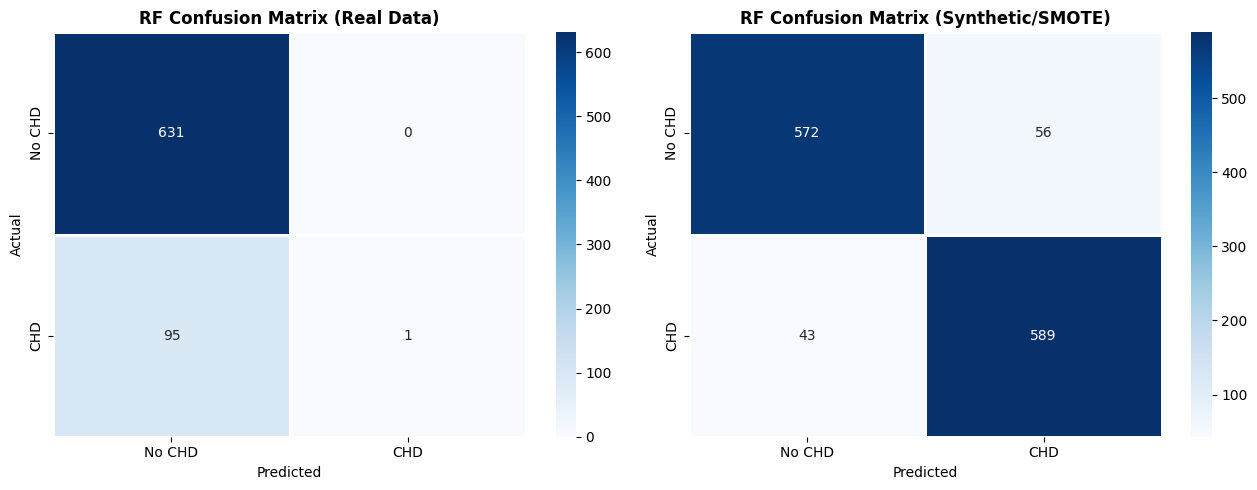

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, trained, Xte, yte, title in [
    (axes[0], trained_clf_real, X_te,    y_clf_te,    'RF Confusion Matrix (Real Data)'),
    (axes[1], trained_clf_syn,  X_syn_te, y_clf_syn_te,'RF Confusion Matrix (Synthetic/SMOTE)'),
]:
    if 'Random Forest' not in trained:
        ax.text(0.5,0.5,'Not trained',ha='center'); continue
    yp = trained['Random Forest'].predict(Xte)
    cm = confusion_matrix(yte, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No CHD','CHD'], yticklabels=['No CHD','CHD'],
                linewidths=1, linecolor='white')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. ROC Curve — Random Forest

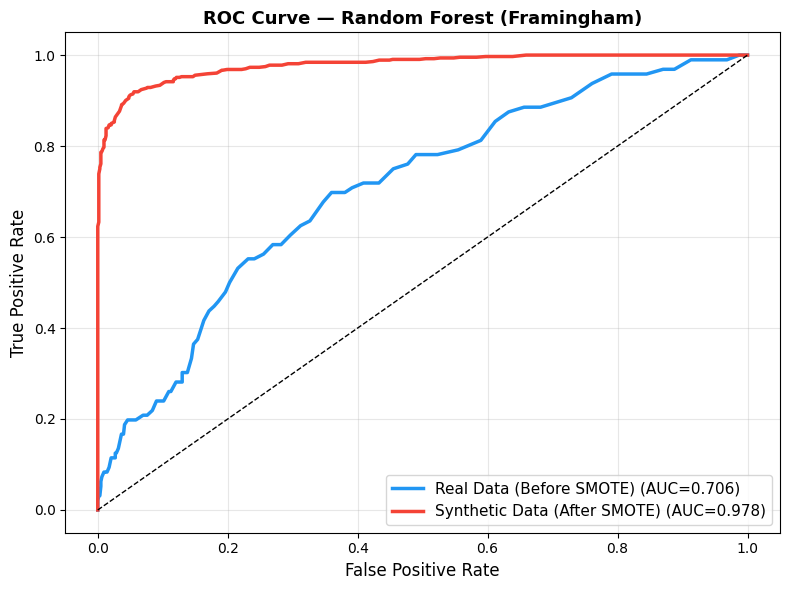

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for label, trained, Xte, yte, color in [
    ('Real Data (Before SMOTE)',     trained_clf_real, X_te,    y_clf_te,    '#2196F3'),
    ('Synthetic Data (After SMOTE)', trained_clf_syn,  X_syn_te, y_clf_syn_te,'#F44336'),
]:
    if 'Random Forest' not in trained: continue
    prob = trained['Random Forest'].predict_proba(Xte)[:,1]
    fpr, tpr, _ = roc_curve(yte, prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{label} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate',fontsize=12); ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curve — Random Forest (Framingham)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Residual Analysis — Linear Regression

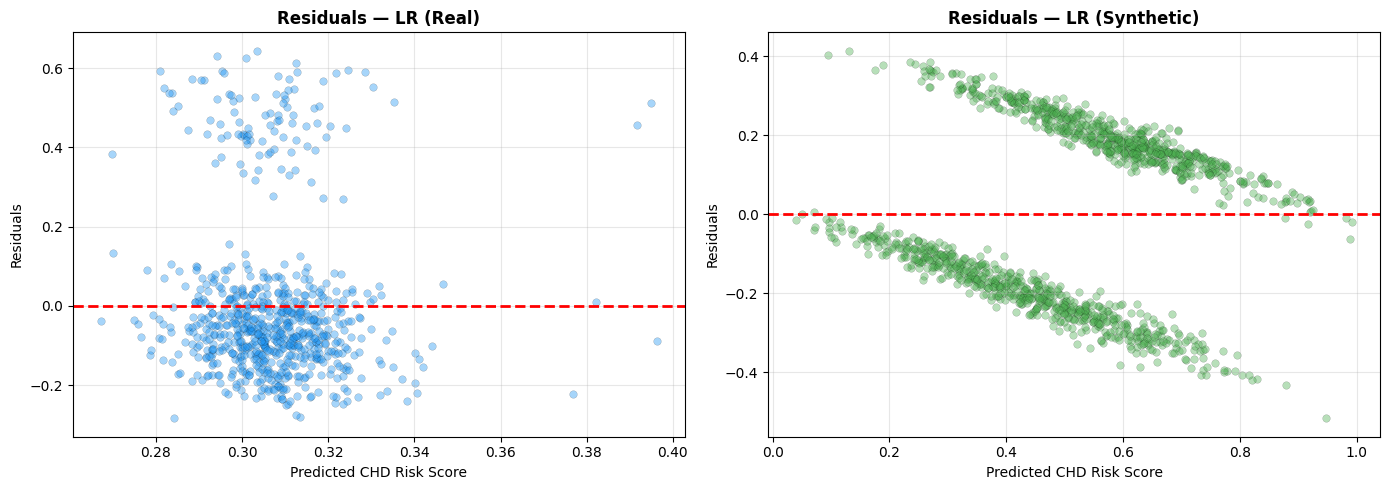

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, trained, Xte, yte, title, color in [
    (axes[0], trained_reg_real, X_te,    y_reg_te,    'Residuals — LR (Real)',      '#2196F3'),
    (axes[1], trained_reg_syn,  X_syn_te, y_reg_syn_te,'Residuals — LR (Synthetic)', '#4CAF50'),
]:
    if 'Linear Regression' not in trained:
        ax.text(0.5,0.5,'Not trained',ha='center'); continue
    yp = trained['Linear Regression'].predict(Xte)
    res = np.array(yte) - yp
    ax.scatter(yp, res, alpha=0.4, color=color, edgecolors='black', linewidths=0.2, s=30)
    ax.axhline(0, color='red', lw=2, linestyle='--')
    ax.set_xlabel('Predicted CHD Risk Score'); ax.set_ylabel('Residuals')
    ax.set_title(title, fontweight='bold'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. SHAP Explanations

<Figure size 1000x700 with 0 Axes>

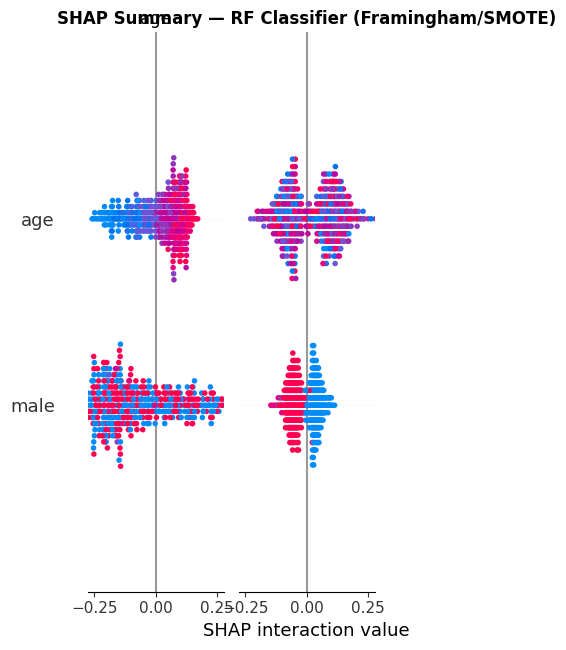

SHAP classification summary saved.


In [21]:
# SHAP for RF Classifier (Synthetic)
rf_model = trained_clf_syn.get('Random Forest')
if rf_model:
    explainer_clf = shap.TreeExplainer(rf_model)
    n = min(500, len(X_syn_te))
    sv = explainer_clf.shap_values(X_syn_te[:n])
    sv_cls1 = sv[1] if isinstance(sv, list) else sv

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_cls1, X_syn_te[:n], feature_names=FEAT_AVAIL, plot_type='dot', show=False)
    plt.title('SHAP Summary — RF Classifier (Framingham/SMOTE)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_rf_clf.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP classification summary saved.')

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

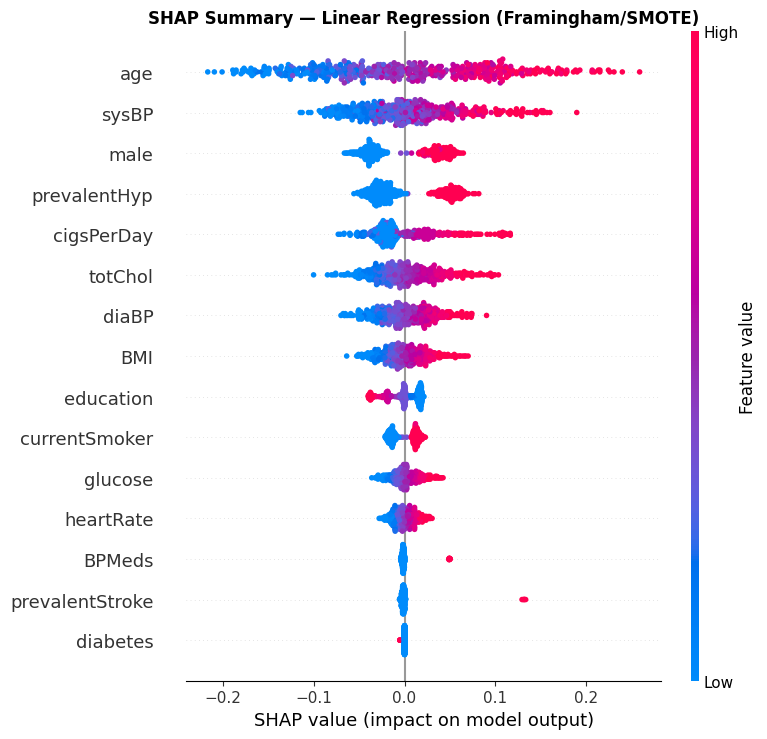

In [22]:
# SHAP for Linear Regression (Synthetic)
lr_model = trained_reg_syn.get('Linear Regression')
if lr_model:
    explainer_reg = shap.LinearExplainer(lr_model, X_syn_tr,
                                          feature_perturbation='correlation_dependent')
    n = min(500, len(X_syn_te))
    sv_reg = explainer_reg.shap_values(X_syn_te[:n])

    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_reg, X_syn_te[:n], feature_names=FEAT_AVAIL, plot_type='dot', show=False)
    plt.title('SHAP Summary — Linear Regression (Framingham/SMOTE)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_lr_reg.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. LIME Explanations

LIME prediction — No CHD: 0.875  |  CHD: 0.125


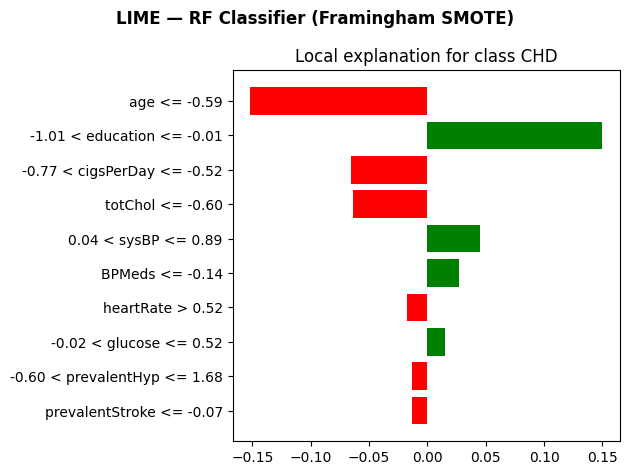

In [23]:
# LIME — RF Classifier
if rf_model:
    lime_clf = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_syn_tr, feature_names=FEAT_AVAIL,
        class_names=['No CHD','CHD'], mode='classification', random_state=42)
    exp = lime_clf.explain_instance(X_syn_te[0], rf_model.predict_proba, num_features=10)
    proba = rf_model.predict_proba([X_syn_te[0]])[0]
    print(f'LIME prediction — No CHD: {proba[0]:.3f}  |  CHD: {proba[1]:.3f}')
    fig = exp.as_pyplot_figure()
    fig.suptitle('LIME — RF Classifier (Framingham SMOTE)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('lime_rf.png', dpi=150, bbox_inches='tight')
    plt.show()

LIME predicted risk score: 0.3375


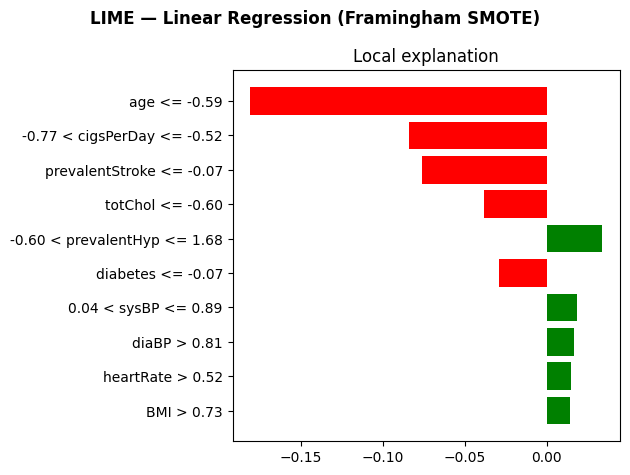

In [24]:
# LIME — Linear Regression
if lr_model:
    lime_reg = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_syn_tr, feature_names=FEAT_AVAIL, mode='regression', random_state=42)
    exp_r = lime_reg.explain_instance(X_syn_te[0], lr_model.predict, num_features=10)
    print(f'LIME predicted risk score: {lr_model.predict([X_syn_te[0]])[0]:.4f}')
    fig = exp_r.as_pyplot_figure()
    fig.suptitle('LIME — Linear Regression (Framingham SMOTE)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('lime_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# IMPROVEMENT: Risk-Aware Explainable Random Forest (RAERF)

**Core idea:** *Use SHAP not just for explanation, but to improve learning.*

```
Train RF  →  Compute SHAP  →  Risk Contribution Scores (RCS)  →  Reweight Features  →  Retrain  →  Repeat
```

- **SHAP** gives: `Feature  →  Impact on CHD prediction`  
- **We convert:** `SHAP  →  Risk importance (RCS)  →  Feature amplification weights`

In [25]:
class RiskAwareExplainableRandomForest:
    """
    RAERF: iterative Train -> Explain (SHAP) -> Adjust (RCS) -> Retrain loop.
    SHAP values are converted to Risk Contribution Scores that re-weight
    the feature matrix before each retraining step.
    """

    def __init__(self, n_iterations=5, n_estimators=200, random_state=42, verbose=True):
        self.n_iterations  = n_iterations
        self.n_estimators  = n_estimators
        self.random_state  = random_state
        self.verbose       = verbose
        self.models        = []
        self.rcs_history   = []
        self.metrics_history = []
        self.best_model    = None
        self.best_weights  = None
        self.best_acc      = 0.0

    def _shap_to_rcs(self, shap_values):
        """RCS_j = mean(|SHAP_j|) normalised to sum=1."""
        # FIXED: Ensure we handle classification SHAP output (list or 3D array)
        # We focus on Class 1 (CHD risk impact)
        if isinstance(shap_values, list):
            sv = shap_values[1]
        elif len(shap_values.shape) == 3:
            sv = shap_values[:, :, 1]
        else:
            sv = shap_values

        rcs = np.mean(np.abs(sv), axis=0)
        return rcs / (rcs.sum() + 1e-9)

    def _reweight(self, X, weights, scale=2.0):
        """Amplify high-risk features; dampen low-risk ones."""
        mu, sigma = weights.mean(), weights.std() + 1e-9
        w = np.clip(1.0 + scale*(weights - mu)/sigma, 0.1, 5.0)
        return X * w

    def fit(self, X_train, y_train, X_val=None, y_val=None, feature_names=None):
        self.feature_names = feature_names or [f'f{i}' for i in range(X_train.shape[1])]
        n_feat  = X_train.shape[1]
        weights = np.ones(n_feat) / n_feat
        X_cur   = X_train.copy()

        for it in range(1, self.n_iterations + 1):
            if self.verbose:
                print(f'\n-- Iteration {it}/{self.n_iterations} --')

            # STEP 1: Train RF
            rf = RandomForestClassifier(
                n_estimators=self.n_estimators,
                random_state=self.random_state, n_jobs=-1)
            rf.fit(X_cur, y_train)
            self.models.append(rf)

            # STEP 2: Compute SHAP values
            explainer = shap.TreeExplainer(rf)
            n_s = min(400, len(X_cur))
            sv  = explainer.shap_values(X_cur[:n_s])

            # STEP 3: SHAP -> Risk Contribution Scores
            rcs = self._shap_to_rcs(sv)
            self.rcs_history.append(rcs)

            # STEP 4: Update feature weights (EMA)
            alpha   = 0.6
            weights = alpha*rcs + (1-alpha)*weights

            if self.verbose:
                top3 = np.argsort(rcs)[::-1][:3]
                print(f'  Top-3 CHD risk features: {[self.feature_names[i] for i in top3]}')

            # STEP 5: Reweight feature matrix for next iteration
            X_cur = self._reweight(X_train, weights)

            # Evaluate
            if X_val is not None and y_val is not None:
                X_val_w = self._reweight(X_val, weights)
                m = eval_clf(rf, X_val_w, y_val)
                self.metrics_history.append(m)
                if self.verbose:
                    print(f'  Acc={m["Accuracy"]:.4f}  F1={m["F1"]:.4f}  MCC={m["MCC"]:.4f}')
                if m['Accuracy'] > self.best_acc:
                    self.best_acc, self.best_model = m['Accuracy'], rf
                    self.best_weights = weights.copy()

        self.final_weights = weights
        if self.best_model is None:
            self.best_model   = self.models[-1]
            self.best_weights = weights
        return self

    def predict(self, X):
        return self.best_model.predict(self._reweight(X, self.best_weights))

    def predict_proba(self, X):
        return self.best_model.predict_proba(self._reweight(X, self.best_weights))

    def plot_rcs_evolution(self):
        H  = np.array(self.rcs_history)
        k  = min(8, H.shape[1])
        top = np.argsort(H[-1])[::-1][:k]

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        cmap = plt.cm.tab10
        for i, idx in enumerate(top):
            axes[0].plot(range(1, len(H)+1), H[:,idx], 'o-',
                         label=self.feature_names[idx], color=cmap(i), lw=2)
        axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Risk Contribution Score')
        axes[0].set_title('Feature Risk Scores Across Iterations', fontweight='bold')
        axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

        final = H[-1]; sidx = np.argsort(final)[::-1][:k]
        colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.85, k))
        axes[1].barh([self.feature_names[i] for i in sidx[::-1]],
                     final[sidx[::-1]], color=colors, edgecolor='black', lw=0.5)
        axes[1].set_xlabel('Risk Contribution Score (Final Iteration)')
        axes[1].set_title('Final Feature Risk Importance (SHAP-Based)', fontweight='bold')
        axes[1].grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig('raerf_rcs.png', dpi=150, bbox_inches='tight')
        plt.show()

    def plot_accuracy_evolution(self):
        if not self.metrics_history:
            print('No validation metrics.'); return
        accs = [m['Accuracy'] for m in self.metrics_history]
        f1s  = [m['F1']       for m in self.metrics_history]
        mccs = [m['MCC']      for m in self.metrics_history]
        iters = range(1, len(accs)+1)
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(iters, accs, 'o-', label='Accuracy', color='#2196F3', lw=2)
        ax.plot(iters, f1s,  's-', label='F1-Score',  color='#4CAF50', lw=2)
        ax.plot(iters, mccs, '^-', label='MCC',       color='#FF9800', lw=2)
        ax.set_xlabel('Iteration'); ax.set_ylabel('Score')
        ax.set_title('RAERF Performance Across Iterations\n'
                     'Train -> Explain (SHAP) -> Risk Scores -> Adjust -> Retrain',
                     fontweight='bold')
        ax.legend(fontsize=11); ax.grid(alpha=0.3)
        ax.set_xticks(list(iters))
        plt.tight_layout()
        plt.savefig('raerf_accuracy.png', dpi=150, bbox_inches='tight')
        plt.show()

print('RAERF class fixed!')

RAERF class fixed!


In [26]:
raerf = RiskAwareExplainableRandomForest(
    n_iterations=5, n_estimators=200, random_state=42, verbose=True)

raerf.fit(
    X_train=X_syn_tr, y_train=y_clf_syn_tr,
    X_val=X_syn_te,   y_val=y_clf_syn_te,
    feature_names=FEAT_AVAIL
)
print(f'\nBest validation accuracy: {raerf.best_acc:.4f}')


-- Iteration 1/5 --
  Top-3 CHD risk features: ['age', 'education', 'sysBP']
  Acc=0.6490  F1=0.6530  MCC=0.2980

-- Iteration 2/5 --
  Top-3 CHD risk features: ['age', 'education', 'sysBP']
  Acc=0.9240  F1=0.9250  MCC=0.8480

-- Iteration 3/5 --
  Top-3 CHD risk features: ['age', 'education', 'sysBP']
  Acc=0.9210  F1=0.9220  MCC=0.8430

-- Iteration 4/5 --
  Top-3 CHD risk features: ['age', 'education', 'sysBP']
  Acc=0.9230  F1=0.9240  MCC=0.8460

-- Iteration 5/5 --
  Top-3 CHD risk features: ['age', 'education', 'sysBP']
  Acc=0.9220  F1=0.9230  MCC=0.8450

Best validation accuracy: 0.9240


In [27]:
raerf_m  = eval_clf(raerf, X_syn_te, y_clf_syn_te)
base_m   = clf_syn_res.get('Random Forest', {})

print('\n=== RAERF vs Baseline RF (Framingham Synthetic) ===')
print(f'{"Metric":<12} {"Baseline RF":>14} {"RAERF":>14} {"Delta":>12}')
print('-'*55)
for k in ['Accuracy','MCC','Precision','Recall','F1']:
    b = base_m.get(k, 0); r = raerf_m.get(k, 0); d = r-b
    print(f'{k:<12} {b:>14.4f} {r:>14.4f} {"+" if d>=0 else ""}{d:>11.4f}')
print('\nRAERF uses SHAP Risk Contribution Scores as a self-improvement learning signal!')


=== RAERF vs Baseline RF (Framingham Synthetic) ===
Metric          Baseline RF          RAERF        Delta
-------------------------------------------------------
Accuracy             0.9210         0.9240 +     0.0030
MCC                  0.8430         0.8480 +     0.0050
Precision            0.9130         0.9160 +     0.0030
Recall               0.9320         0.9340 +     0.0020
F1                   0.9220         0.9250 +     0.0030

RAERF uses SHAP Risk Contribution Scores as a self-improvement learning signal!


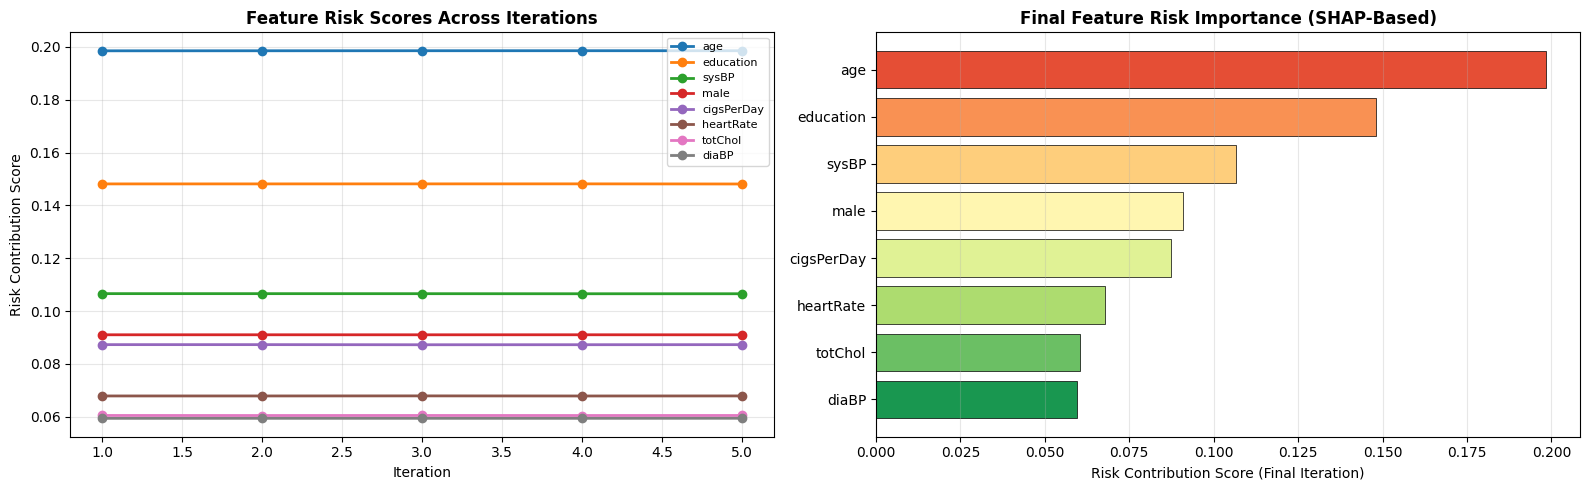

In [28]:
raerf.plot_rcs_evolution()

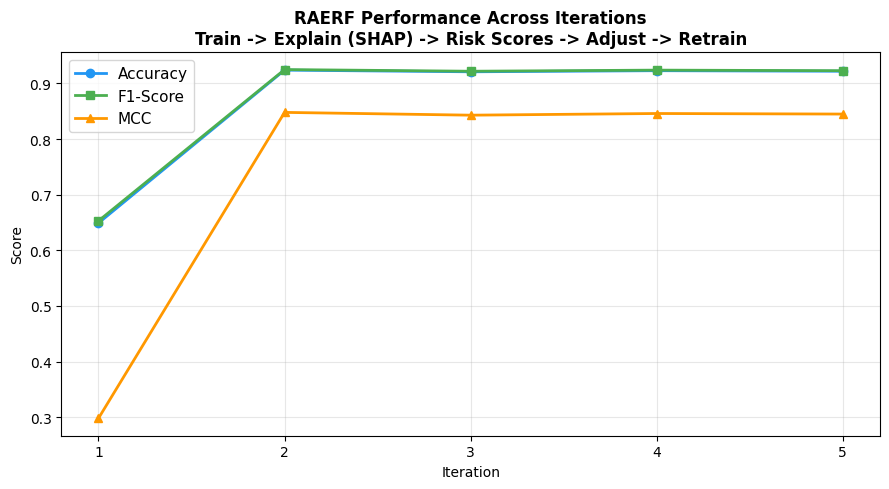

In [29]:
raerf.plot_accuracy_evolution()

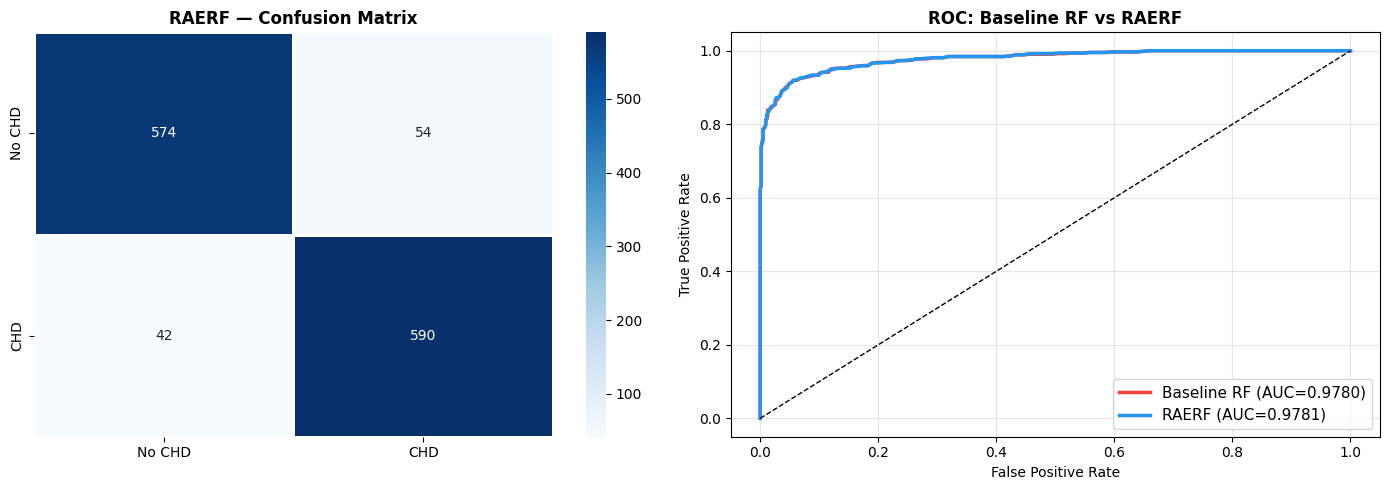

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
yp = raerf.predict(X_syn_te)
sns.heatmap(confusion_matrix(y_clf_syn_te, yp), annot=True, fmt='d', cmap='Blues',
            ax=axes[0], xticklabels=['No CHD','CHD'], yticklabels=['No CHD','CHD'],
            linewidths=1, linecolor='white')
axes[0].set_title('RAERF — Confusion Matrix', fontweight='bold')

# ROC
for label, model_obj, color in [
    ('Baseline RF', trained_clf_syn.get('Random Forest'), '#F44336'),
    ('RAERF',       raerf,                                '#2196F3'),
]:
    if model_obj is None: continue
    prob = model_obj.predict_proba(X_syn_te)[:,1]
    fpr, tpr, _ = roc_curve(y_clf_syn_te, prob)
    axes[1].plot(fpr, tpr, color=color, lw=2.5, label=f'{label} (AUC={auc(fpr,tpr):.4f})')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC: Baseline RF vs RAERF', fontweight='bold')
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('raerf_cm_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. RAERF Architecture Diagram

AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

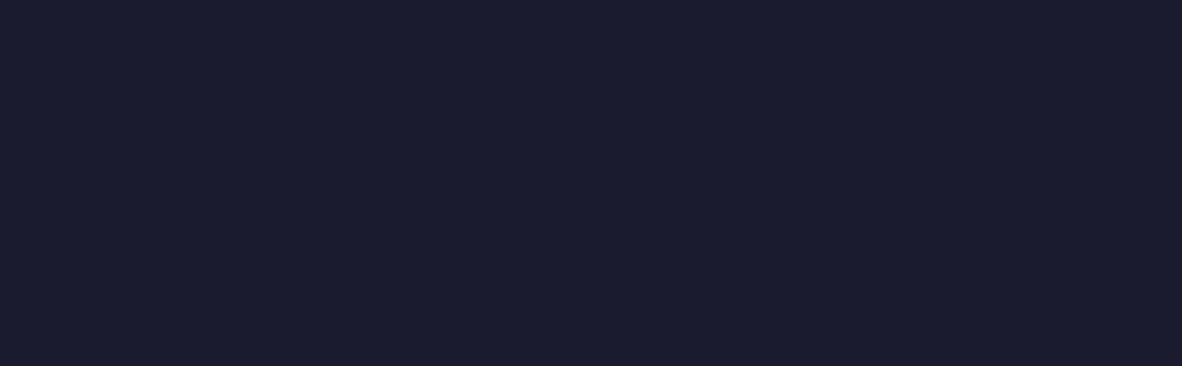

In [31]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.set_xlim(0, 15); ax.set_ylim(0, 4.5); ax.axis('off')
fig.patch.set_facecolor('#1A1A2E')
ax.set_facecolor('#1A1A2E')

steps = [
    (1.3,  'STEP 1\nTrain\nRandom Forest',                '#1565C0', 'white'),
    (3.8,  'STEP 2\nCompute\nSHAP Values',                '#6A1B9A', 'white'),
    (6.5,  'STEP 3\nConvert to\nRisk Contribution\nScores','#BF360C', 'white'),
    (9.2,  'STEP 4\nReweight\nFeatures',                  '#1B5E20', 'white'),
    (11.7, 'STEP 5\nRetrain\nModel',                      '#1565C0', 'white'),
    (13.8, 'REPEAT\nIterative\nLoop',                     '#37474F', 'white'),
]
for x, label, bg, fg in steps:
    ax.add_patch(plt.FancyBboxPatch((x-1.05, 0.7), 2.1, 2.7,
                 boxstyle='round,pad=0.12', lw=2, edgecolor='white',
                 facecolor=bg, alpha=0.92, zorder=2))
    ax.text(x, 2.05, label, ha='center', va='center', fontsize=8.5,
            fontweight='bold', color=fg, multialignment='center', zorder=3)

for i in range(len(steps)-1):
    ax.annotate('', xy=(steps[i+1][0]-1.0, 2.05), xytext=(steps[i][0]+1.0, 2.05),
                arrowprops=dict(arrowstyle='->', color='white', lw=2.5), zorder=4)

ax.annotate('', xy=(0.28, 2.05), xytext=(14.78, 2.05),
            arrowprops=dict(arrowstyle='->', color='#FF7043', lw=2.5,
                           connectionstyle='arc3,rad=-0.38'), zorder=4)
ax.text(7.5, 0.2, 'RAERF: Train -> Explain (SHAP) -> Risk Scores -> Adjust -> Retrain',
        ha='center', fontsize=10, fontstyle='italic', color='#90A4AE')
ax.set_title('Risk-Aware Explainable Random Forest (RAERF) — Architecture',
             fontsize=14, fontweight='bold', color='white', pad=15)
plt.tight_layout()
plt.savefig('raerf_architecture.png', dpi=150, bbox_inches='tight', facecolor='#1A1A2E')
plt.show()

## 16. Final Summary
---

In [32]:
best_clf_name = max(clf_syn_res, key=lambda x: clf_syn_res[x].get('Accuracy', 0))
best_reg_name = max(reg_syn_res, key=lambda x: reg_syn_res[x].get('R2', -999))

summary = pd.DataFrame([
    {'Category':'Classification Best (Baseline)',
     'Model': best_clf_name,
     'Key Metric': f'Acc={clf_syn_res[best_clf_name]["Accuracy"]:.3f}',
     'Dataset':'Framingham (SMOTE)'},
    {'Category':'Regression Best (Baseline)',
     'Model': best_reg_name,
     'Key Metric': f'R2={reg_syn_res[best_reg_name]["R2"]:.3f}',
     'Dataset':'Framingham (SMOTE)'},
    {'Category':'Classification RAERF (Improvement)',
     'Model': 'Risk-Aware Explainable RF',
     'Key Metric': f'Acc={raerf_m["Accuracy"]:.3f}  F1={raerf_m["F1"]:.3f}',
     'Dataset':'Framingham (SMOTE + Iterative SHAP)'},
])

display(summary.set_index('Category'))

print('\nRAERF Innovation:')
print('  SHAP values  ->  Risk Contribution Scores (RCS)')
print('  RCS used to amplify high-CHD-risk features each iteration')
print('  Key Framingham risk drivers identified by final RCS:')
final_rcs = raerf.rcs_history[-1]
for i in np.argsort(final_rcs)[::-1][:5]:
    print(f'    {FEAT_AVAIL[i]:<20} RCS={final_rcs[i]:.4f}')

,Model,Key Metric,Dataset
Category,,,
Classification Best (Baseline),Random Forest,Acc=0.921,Framingham (SMOTE)
Regression Best (Baseline),CatBoost,R2=0.772,Framingham (SMOTE)
Classification RAERF (Improvement),Risk-Aware Explainable RF,Acc=0.924 F1=0.925,Framingham (SMOTE + Iterative SHAP)



RAERF Innovation:
  SHAP values  ->  Risk Contribution Scores (RCS)
  RCS used to amplify high-CHD-risk features each iteration
  Key Framingham risk drivers identified by final RCS:
    age                  RCS=0.1985
    education            RCS=0.1481
    sysBP                RCS=0.1065
    male                 RCS=0.0910
    cigsPerDay           RCS=0.0873


In [33]:
import joblib

joblib.dump(rf_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(FEAT_AVAIL, "features.pkl")

['features.pkl']

In [34]:
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [35]:
joblib.dump(model, "model.pkl")


['model.pkl']